# 07 — Esperimento supplementare: quanti cicli mancano alla soglia critica

Una stima di State of Health, da sola, non è ciò che serve a chi gestisce una batteria.
La domanda operativa è **quando** la cella scenderà sotto la soglia oltre la quale va
sostituita, che per le celle agli ioni di litio si colloca convenzionalmente attorno al
70–80 % della capacità iniziale.

Questo notebook trasforma le previsioni della pipeline in quella grandezza e ne misura
l'accuratezza. È un esperimento supplementare, non una quinta domanda di ricerca: serve a
mostrare cosa si ottiene dai modelli quando li si usa per ciò a cui servirebbero, e a
quantificare quanto l'errore sul SoH si amplifichi nel passaggio.

**Input:** `results/predictions/03_predizioni.csv`, prodotto dal notebook 03.

**Output**

| percorso | contenuto |
|---|---|
| `results/tables/07_rul_stime.csv` | ciclo di superamento stimato e reale, per blocco e modello |
| `results/tables/07_rul_errori.csv` | errore della stima, per modello e insieme |
| `results/figures/07_rul_*.png` | traiettorie ed errori |


## 1. Configurazione


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except ImportError:
    pass


def find_project_root():
    candidate_paths = [
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/drive/My Drive/SoH_Neural_Tracker"),
        Path.cwd(), *Path.cwd().parents,
    ]
    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
PREDICTIONS_DIR = PROJECT_ROOT / "results" / "predictions"
for cartella in [TABLES_DIR, FIGURES_DIR]:
    cartella.mkdir(parents=True, exist_ok=True)

# Percorso esplicito e non una ricerca fra i file presenti: in una cartella dove
# convivono più file di predizioni, prenderne uno qualunque produrrebbe risultati
# corretti nella forma e riferiti a un esperimento diverso.
percorso_predizioni = PREDICTIONS_DIR / "03_predizioni.csv"
percorso_cicli = DATA_PROCESSED / "battery_cycles.csv"

for percorso, prodotto_da in [(percorso_predizioni, "03_training"),
                              (percorso_cicli, "01_preprocessing")]:
    assert percorso.exists(), (
        f"manca {percorso.relative_to(PROJECT_ROOT)}: esegui prima {prodotto_da}.ipynb"
    )

predizioni = pd.read_csv(percorso_predizioni)
df = pd.read_csv(percorso_cicli)

# L'unità di analisi è il blocco di protocollo. Se il file delle previsioni riporta
# solo la cella, il blocco viene recuperato dal dataset dei cicli: le due celle a
# protocollo misto contribuiscono altrimenti con due traiettorie sovrapposte.
if "protocol_block" not in predizioni.columns:
    mappa = df[["battery_id", "discharge_cycle", "protocol_block"]].rename(
        columns={"discharge_cycle": "target_cycle"})
    predizioni = predizioni.merge(mappa, on=["battery_id", "target_cycle"], how="left")
    assert predizioni.protocol_block.notna().all(), (
        "alcune previsioni non trovano corrispondenza in battery_cycles.csv"
    )
    print("Blocco di protocollo ricostruito dal dataset dei cicli.")

print("Predizioni:", percorso_predizioni.name, f"({len(predizioni)} righe)")
print("Modelli:", ", ".join(sorted(predizioni.modello.unique())))
print("Insiemi:", ", ".join(sorted(predizioni.insieme.unique())))


Mounted at /content/drive
Predizioni: 03_predizioni.csv (3980 righe)
Modelli: Baseline persistenza, GRU, LSTM, MLP, SimpleRNN
Insiemi: test_id, test_ood, train, validation


## 2. La soglia e cosa significa stimarne il superamento

La soglia di fine vita è convenzionale: si adotta **0.80**, valore usato per le
applicazioni automobilistiche, e si riporta anche **0.70**, tipico degli impieghi
stazionari di seconda vita. Non è una proprietà fisica della cella ma un criterio di
servizio, e va dichiarata come tale.

Il compito diventa: dato lo stato osservato fino a un certo ciclo, stimare **fra quanti
cicli** il SoH scenderà sotto la soglia.

**Quando si fa la stima.** Non a un ciclo fissato uguale per tutti, ma quando ciascun
blocco raggiunge lo stesso **stato di salute**: il primo ciclo in cui il SoH scende sotto
0.85. Un ciclo fissato coglierebbe celle in fasi di vita diverse — al ciclo cinquanta
B0006 è quasi a fine vita e B0018 è a metà — e le stime non sarebbero confrontabili. Con
la soglia di osservazione, tutti i blocchi vengono interrogati nella stessa condizione:
*«sono al 85 %, quanto manca al 80 %?»*.

**Come si stima.** Il modello del notebook 03 prevede un ciclo alla volta: non produce
direttamente una data di superamento. Si stima quindi la pendenza della traiettoria sugli
ultimi cicli osservati e la si estrapola fino alla soglia.

La pendenza è calcolata con lo **stimatore di Theil e Sen**: la mediana delle pendenze fra
tutte le coppie di punti, invece della retta ai minimi quadrati. Il motivo è che il SoH
misurato contiene singoli cicli anomali, e ai minimi quadrati un punto fuori linea vicino
al bordo della finestra sposta la pendenza di molto; sulla mediana delle pendenze non ha
quasi effetto. Su questi dati la differenza fra i due stimatori arriva a una decina di
cicli sulla stima finale.

**I limiti, dichiarati.** L'ipotesi di andamento lineare è falsa: il degrado accelera a
fine vita, quindi l'estrapolazione tende a collocare il superamento più tardi del vero. E
se la pendenza stimata è piatta o positiva la soglia non viene mai raggiunta: quel caso
viene riportato come **censurato** e non come un numero grande, che darebbe l'illusione di
una stima.

Il confronto con la stessa procedura applicata alla traiettoria *reale* separa l'errore
del metodo da quello del modello.


In [2]:
SOGLIE = [0.80, 0.70]
SOGLIA_OSSERVAZIONE = 0.85   # stato di salute al momento in cui si fa la stima
FINESTRA_PENDENZA = 40       # cicli di storia su cui stimare la pendenza
ORIZZONTE_MASSIMO = 300      # oltre questo la stima si dichiara censurata

# Una cella arriva sotto soglia solo se la sua traiettoria osservata ci arriva davvero:
# per le altre il valore reale non esiste e la stima non è verificabile.
copertura = (df[df.is_valid].groupby("protocol_block")
             .agg(soh_minimo=("soh", "min"), n_cicli=("soh", "size"))
             .reset_index())
for soglia in SOGLIE:
    copertura[f"scende_sotto_{soglia}"] = copertura.soh_minimo < soglia

display(copertura.round(4))

for soglia in SOGLIE:
    quanti = int(copertura[f"scende_sotto_{soglia}"].sum())
    print(f"Blocchi che scendono sotto {soglia}: {quanti} su {len(copertura)}")


,protocol_block,soh_minimo,n_cicli,scende_sotto_0.8,scende_sotto_0.7
0,B0005_p1,0.7015,168,True,False
1,B0006_p1,0.5731,168,True,True
2,B0007_p1,0.7447,168,True,False
3,B0018_p1,0.7290,132,True,False
4,B0029_p1,0.8878,40,False,False
5,B0030_p1,0.8921,40,False,False
6,B0031_p1,0.9237,40,False,False
7,B0032_p1,0.8769,40,False,False
8,B0042_p1,0.9059,40,False,False
9,B0042_p2,0.7739,25,True,False


Blocchi che scendono sotto 0.8: 6 su 12
Blocchi che scendono sotto 0.7: 1 su 12


In [3]:
SOGLIA = max(s for s in SOGLIE
             if copertura[f"scende_sotto_{s}"].sum() >= 3)
print(f"Soglia di fine vita usata: {SOGLIA}")
print(f"Soglia di osservazione:    {SOGLIA_OSSERVAZIONE}")
print("La prima è la più alta fra quelle candidate per cui almeno tre blocchi arrivano")
print("davvero sotto soglia: sotto quel numero il confronto non avrebbe basi.")


Soglia di fine vita usata: 0.8
Soglia di osservazione:    0.85
La prima è la più alta fra quelle candidate per cui almeno tre blocchi arrivano
davvero sotto soglia: sotto quel numero il confronto non avrebbe basi.


## 3. Ciclo di superamento reale

Il valore di riferimento è il primo ciclo in cui il SoH osservato scende sotto la soglia e
**vi resta**. La condizione di permanenza serve perché il SoH misurato oscilla: un singolo
ciclo sotto soglia seguito da una risalita è rumore di misura, non fine vita.


In [4]:
def primo_superamento(soh, cicli, soglia, persistenza=3):
    """Primo ciclo in cui il SoH scende sotto soglia e vi resta per `persistenza` cicli."""
    sotto = np.asarray(soh) < soglia
    for i in range(len(sotto) - persistenza + 1):
        if sotto[i:i + persistenza].all():
            return int(cicli[i])
    return None


superamenti_reali, osservazioni = {}, {}
for blocco, gruppo in df[df.is_valid].groupby("protocol_block"):
    gruppo = gruppo.sort_values("discharge_cycle")
    soh = gruppo.soh.to_numpy()
    cicli = gruppo.discharge_cycle.to_numpy()

    fine_vita = primo_superamento(soh, cicli, SOGLIA)
    osservazione = primo_superamento(soh, cicli, SOGLIA_OSSERVAZIONE)
    if fine_vita is not None and osservazione is not None and osservazione < fine_vita:
        superamenti_reali[blocco] = fine_vita
        osservazioni[blocco] = osservazione

riferimenti = pd.DataFrame([{
    "protocol_block": blocco,
    "ciclo_osservazione": osservazioni[blocco],
    "superamento_reale": superamenti_reali[blocco],
    "cicli_residui_reali": superamenti_reali[blocco] - osservazioni[blocco],
} for blocco in sorted(superamenti_reali)])

display(riferimenti)
print(f"\nBlocchi utilizzabili: {len(riferimenti)}. Per gli altri la traiettoria non")
print(f"attraversa entrambe le soglie, quindi il valore reale non esiste e la stima")
print("non sarebbe verificabile.")


,protocol_block,ciclo_osservazione,superamento_reale,cicli_residui_reali
0,B0005_p1,80,106,26
1,B0006_p1,52,60,8
2,B0007_p1,85,124,39
3,B0018_p1,62,77,15
4,B0042_p2,96,106,10
5,B0043_p2,99,106,7



Blocchi utilizzabili: 6. Per gli altri la traiettoria non
attraversa entrambe le soglie, quindi il valore reale non esiste e la stima
non sarebbe verificabile.


## 4. La stima a partire dalle previsioni

Per ogni blocco e per ogni modello si prende la traiettoria prevista, si stima la pendenza
sugli ultimi `FINESTRA_PENDENZA` cicli disponibili prima di un punto di osservazione, e si
estrapola fino alla soglia.

Il punto di osservazione è scelto **prima** del superamento reale, così che la stima sia
una previsione e non una constatazione: si usa il ciclo che dista dal superamento reale
quanto la finestra di stima, cioè il momento in cui un operatore avrebbe appena
abbastanza storia per fare la valutazione.


In [5]:
MINIMO_PUNTI = 8


def pendenza_robusta(x, y):
    """Stimatore di Theil e Sen: mediana delle pendenze fra tutte le coppie di punti.

    Preferito ai minimi quadrati perché il SoH misurato contiene cicli anomali isolati,
    e un punto fuori linea vicino al bordo della finestra sposterebbe di molto una retta
    ai minimi quadrati.
    """
    differenze_x = x[None, :] - x[:, None]
    differenze_y = y[None, :] - y[:, None]
    valide = np.triu(differenze_x != 0, k=1)
    if not valide.any():
        return None, None
    pendenze = differenze_y[valide] / differenze_x[valide]
    pendenza = float(np.median(pendenze))
    intercetta = float(np.median(y - pendenza * x))
    return pendenza, intercetta


def stima_superamento(cicli, valori, ciclo_osservazione, soglia,
                      finestra=FINESTRA_PENDENZA):
    """Estrapola la pendenza recente fino alla soglia.

    Restituisce il ciclo stimato, oppure None se la pendenza non è negativa o se la
    stima cade oltre l'orizzonte massimo: in quei casi la traiettoria osservata non
    porta alla soglia, e restituire un numero grande darebbe l'illusione di una stima.
    """
    maschera = (cicli <= ciclo_osservazione) & (cicli > ciclo_osservazione - finestra)
    if maschera.sum() < MINIMO_PUNTI:
        maschera = cicli <= ciclo_osservazione
    if maschera.sum() < MINIMO_PUNTI:
        return None

    pendenza, intercetta = pendenza_robusta(cicli[maschera], valori[maschera])
    if pendenza is None or pendenza >= -1e-6:
        return None

    stima = float((soglia - intercetta) / pendenza)
    if stima > ciclo_osservazione + ORIZZONTE_MASSIMO:
        return None
    return stima


righe, esclusi = [], {}
for (modello, blocco), gruppo in predizioni.groupby(["modello", "protocol_block"]):
    if blocco not in superamenti_reali:
        continue
    gruppo = gruppo.sort_values("target_cycle")
    cicli = gruppo.target_cycle.to_numpy(float)
    reale = superamenti_reali[blocco]
    ciclo_osservazione = osservazioni[blocco]

    # Servono almeno MINIMO_PUNTI previsioni prima del momento della stima. I blocchi
    # brevi non ne hanno: le previsioni cominciano dopo i primi WINDOW_SIZE cicli, e
    # se il blocco raggiunge presto la soglia di osservazione la storia non basta.
    disponibili = int((cicli <= ciclo_osservazione).sum())
    if disponibili < MINIMO_PUNTI:
        esclusi[blocco] = disponibili
        continue

    stima_modello = stima_superamento(cicli, gruppo.soh_previsto.to_numpy(float),
                                      ciclo_osservazione, SOGLIA)
    stima_reale = stima_superamento(cicli, gruppo.soh_vero.to_numpy(float),
                                    ciclo_osservazione, SOGLIA)

    righe.append({
        "modello": modello,
        "blocco": blocco,
        "insieme": gruppo.insieme.iloc[0],
        "ciclo_osservazione": ciclo_osservazione,
        "superamento_reale": reale,
        "stima_da_previsioni": stima_modello,
        "stima_da_traiettoria_vera": stima_reale,
        "censurata": stima_modello is None,
        "cicli_residui_reali": reale - ciclo_osservazione,
    })

stime = pd.DataFrame(righe)
assert len(stime), (
    f"nessun blocco utilizzabile alla soglia {SOGLIA}: servono blocchi che scendano "
    f"sotto soglia avendo almeno {FINESTRA_PENDENZA + 5} cicli di storia prima del "
    f"superamento. Blocchi che scendono sotto soglia: {sorted(superamenti_reali)}"
)
stime["errore_modello"] = stime.stima_da_previsioni - stime.superamento_reale
stime["errore_estrapolazione"] = stime.stima_da_traiettoria_vera - stime.superamento_reale

display(stime.round(1))
stime.to_csv(TABLES_DIR / "07_rul_stime.csv", index=False)

if esclusi:
    print("\nBlocchi esclusi per storia insufficiente prima del momento della stima:")
    for blocco, disponibili in sorted(esclusi.items()):
        print(f"  {blocco:12s} {disponibili} previsioni disponibili, "
              f"ne servono {MINIMO_PUNTI}")
    print("Sono blocchi brevi che raggiungono presto la soglia di osservazione: la")
    print("stima sarebbe possibile solo accorciando la finestra fino a renderla instabile.")


,modello,blocco,insieme,ciclo_osservazione,superamento_reale,stima_da_previsioni,stima_da_traiettoria_vera,censurata,cicli_residui_reali,errore_modello,errore_estrapolazione
0,Baseline persistenza,B0005_p1,train,80,106,95.3,94.1,False,26,-10.7,-11.9
1,Baseline persistenza,B0006_p1,train,52,60,70.2,68.6,False,8,10.2,8.6
2,Baseline persistenza,B0007_p1,validation,85,124,101.4,100.4,False,39,-22.6,-23.6
3,Baseline persistenza,B0018_p1,test_id,62,77,95.0,92.4,False,15,18.0,15.4
4,GRU,B0005_p1,train,80,106,94.7,94.1,False,26,-11.3,-11.9
5,GRU,B0006_p1,train,52,60,67.2,68.6,False,8,7.2,8.6
6,GRU,B0007_p1,validation,85,124,103.9,100.4,False,39,-20.1,-23.6
7,GRU,B0018_p1,test_id,62,77,94.1,92.4,False,15,17.1,15.4
8,LSTM,B0005_p1,train,80,106,95.3,94.1,False,26,-10.7,-11.9
9,LSTM,B0006_p1,train,52,60,66.2,68.6,False,8,6.2,8.6



Blocchi esclusi per storia insufficiente prima del momento della stima:
  B0042_p2     0 previsioni disponibili, ne servono 8
  B0043_p2     3 previsioni disponibili, ne servono 8
Sono blocchi brevi che raggiungono presto la soglia di osservazione: la
stima sarebbe possibile solo accorciando la finestra fino a renderla instabile.


## 5. Scomposizione dell'errore

L'errore della stima ha due sorgenti, e tenerle separate è il punto dell'esperimento.

**L'errore di estrapolazione** è quello che si commetterebbe conoscendo perfettamente il
SoH: viene dall'ipotesi di andamento lineare, che il degrado a fine vita smentisce. Si
misura applicando la stessa procedura alla traiettoria *vera*.

**L'errore del modello** è quello effettivo, che comprende anche l'imprecisione delle
previsioni. La differenza fra i due dice quanto pesa il modello e quanto pesa il metodo di
estrapolazione: se sono simili, migliorare il modello non servirebbe.


In [6]:
# Le stime censurate non entrano nelle mediane: mediarle con un valore convenzionale
# confonderebbe "non so" con "molto lontano". Vengono contate a parte.
stime_valide = stime[~stime.censurata]

errori = (stime_valide.groupby(["modello", "insieme"])
          .agg(n_blocchi=("blocco", "count"),
               errore_modello_mediano=("errore_modello", "median"),
               errore_modello_assoluto=("errore_modello", lambda s: s.abs().median()),
               errore_estrapolazione_assoluto=(
                   "errore_estrapolazione", lambda s: s.abs().median()),
               cicli_residui_mediani=("cicli_residui_reali", "median"))
          .reset_index())

errori["errore_relativo"] = (errori.errore_modello_assoluto
                             / errori.cicli_residui_mediani)
errori["quota_dovuta_al_metodo"] = (errori.errore_estrapolazione_assoluto
                                    / errori.errore_modello_assoluto)

censurate = (stime.groupby(["modello", "insieme"]).censurata.sum()
             .rename("n_censurate").reset_index())
errori = errori.merge(censurate, on=["modello", "insieme"], how="left")

display(errori.round(3))
errori.to_csv(TABLES_DIR / "07_rul_errori.csv", index=False)

print("\nerrore_relativo: errore in cicli diviso per i cicli residui da stimare.")
print("quota_dovuta_al_metodo: frazione dell'errore già presente conoscendo il SoH vero.")
print("Un valore vicino a 1 significa che l'errore non viene dal modello ma")
print("dall'ipotesi di degrado lineare.")


,modello,insieme,n_blocchi,errore_modello_mediano,errore_modello_assoluto,errore_estrapolazione_assoluto,cicli_residui_mediani,errore_relativo,quota_dovuta_al_metodo,n_censurate
0,Baseline persistenza,test_id,1,17.982,17.982,15.442,15.0,1.199,0.859,0
1,Baseline persistenza,train,2,-0.241,10.483,10.263,17.0,0.617,0.979,0
2,Baseline persistenza,validation,1,-22.639,22.639,23.640,39.0,0.580,1.044,0
3,GRU,test_id,1,17.107,17.107,15.442,15.0,1.140,0.903,0
4,GRU,train,2,-2.034,9.261,10.263,17.0,0.545,1.108,0
5,GRU,validation,1,-20.108,20.108,23.640,39.0,0.516,1.176,0
6,LSTM,test_id,1,19.284,19.284,15.442,15.0,1.286,0.801,0
7,LSTM,train,2,-2.234,8.418,10.263,17.0,0.495,1.219,0
8,LSTM,validation,1,-18.047,18.047,23.640,39.0,0.463,1.310,0
9,MLP,test_id,1,43.597,43.597,15.442,15.0,2.906,0.354,0



errore_relativo: errore in cicli diviso per i cicli residui da stimare.
quota_dovuta_al_metodo: frazione dell'errore già presente conoscendo il SoH vero.
Un valore vicino a 1 significa che l'errore non viene dal modello ma
dall'ipotesi di degrado lineare.


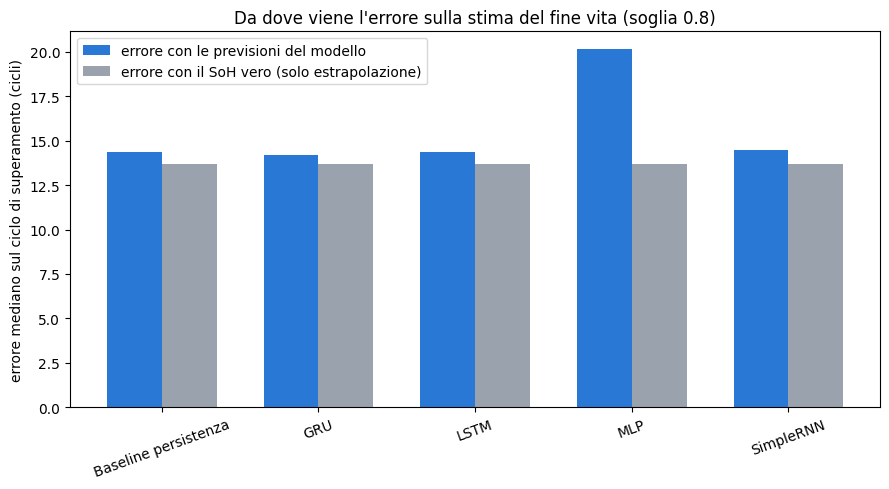

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

modelli = sorted(stime.modello.unique())
posizioni = np.arange(len(modelli))
larghezza = 0.35

modelli = sorted(stime_valide.modello.unique())
posizioni = np.arange(len(modelli))
modello_assoluto = [stime_valide[stime_valide.modello == m].errore_modello.abs().median()
                    for m in modelli]
metodo_assoluto = [stime_valide[stime_valide.modello == m]
                   .errore_estrapolazione.abs().median() for m in modelli]

ax.bar(posizioni - larghezza / 2, modello_assoluto, larghezza,
       label="errore con le previsioni del modello", color="#2a78d6")
ax.bar(posizioni + larghezza / 2, metodo_assoluto, larghezza,
       label="errore con il SoH vero (solo estrapolazione)", color="#9aa3ad")

ax.set_xticks(posizioni)
ax.set_xticklabels(modelli, rotation=20)
ax.set_ylabel("errore mediano sul ciclo di superamento (cicli)")
ax.set_title(f"Da dove viene l'errore sulla stima del fine vita (soglia {SOGLIA})")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_rul_scomposizione_errore.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Una traiettoria per esteso

Un caso singolo, mostrato per intero: la traiettoria osservata, quella prevista, il punto
di osservazione, l'estrapolazione e il superamento reale. Serve a rendere verificabile la
procedura descritta sopra.


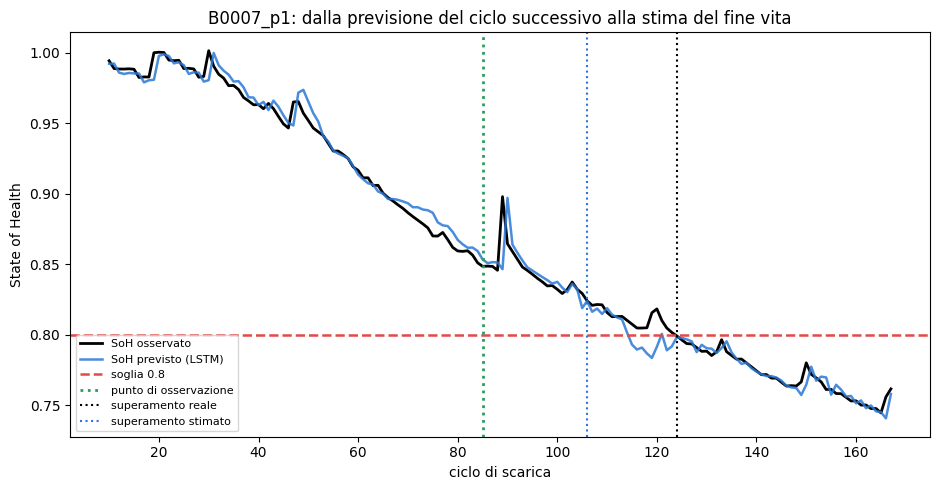

In [8]:
blocco_esempio = (stime_valide.sort_values("cicli_residui_reali", ascending=False)
                  .blocco.iloc[0])
modello_esempio = (stime_valide[stime_valide.blocco == blocco_esempio]
                   .sort_values("errore_modello", key=abs).modello.iloc[0])

traccia = predizioni[(predizioni.modello == modello_esempio)
                     & (predizioni.protocol_block == blocco_esempio)
                     ].sort_values("target_cycle")

riga = stime[(stime.blocco == blocco_esempio)
             & (stime.modello == modello_esempio)].iloc[0]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(traccia.target_cycle, traccia.soh_vero, color="black", lw=2, label="SoH osservato")
ax.plot(traccia.target_cycle, traccia.soh_previsto, color="#2a78d6", lw=1.8,
        alpha=0.85, label=f"SoH previsto ({modello_esempio})")

ax.axhline(SOGLIA, color="#e34948", ls="--", lw=1.8, label=f"soglia {SOGLIA}")
ax.axvline(riga.ciclo_osservazione, color="#2a9d5c", ls=":", lw=2,
           label="punto di osservazione")
ax.axvline(riga.superamento_reale, color="black", ls=":", lw=1.5,
           label="superamento reale")
if pd.notna(riga.stima_da_previsioni):
    ax.axvline(riga.stima_da_previsioni, color="#2a78d6", ls=":", lw=1.5,
               label="superamento stimato")

ax.set_xlabel("ciclo di scarica")
ax.set_ylabel("State of Health")
ax.set_title(f"{blocco_esempio}: dalla previsione del ciclo successivo alla stima "
             f"del fine vita")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_rul_traiettoria.png", dpi=200, bbox_inches="tight")
plt.show()


In [9]:
migliore = errori.sort_values("errore_modello_assoluto").iloc[0]

print("Conclusione dell'esperimento\n")
print(f"Soglia di fine vita {SOGLIA}, stima effettuata quando il SoH scende sotto "
      f"{SOGLIA_OSSERVAZIONE}.")
if int(stime.censurata.sum()):
    print(f"Stime censurate (pendenza non negativa o oltre l'orizzonte): "
          f"{int(stime.censurata.sum())} su {len(stime)}.")
print(f"Migliore combinazione: {migliore.modello} su {migliore.insieme}, errore mediano "
      f"{migliore.errore_modello_assoluto:.0f} cicli su "
      f"{migliore.cicli_residui_mediani:.0f} da stimare "
      f"({migliore.errore_relativo:.0%}).")
print()
if migliore.quota_dovuta_al_metodo > 0.6:
    print("La maggior parte dell'errore è già presente estrapolando la traiettoria vera:")
    print("viene dall'ipotesi di degrado lineare, non dalla qualità delle previsioni.")
    print("Migliorare il modello di un ciclo non migliorerebbe questa stima; servirebbe")
    print("un modello che preveda direttamente l'orizzonte lungo.")
else:
    print("L'errore è dominato dall'imprecisione delle previsioni piuttosto che")
    print("dall'ipotesi di linearità: qui un modello migliore darebbe una stima migliore.")
print()
print("Limiti: la soglia è un criterio di servizio e non una proprietà della cella;")
print("l'estrapolazione lineare sottostima sistematicamente la velocità del degrado a")
print(f"fine vita; e i blocchi utilizzabili sono {len(riferimenti)}, un campione piccolo.")


Conclusione dell'esperimento

Soglia di fine vita 0.8, stima effettuata quando il SoH scende sotto 0.85.
Migliore combinazione: LSTM su train, errore mediano 8 cicli su 17 da stimare (50%).

La maggior parte dell'errore è già presente estrapolando la traiettoria vera:
viene dall'ipotesi di degrado lineare, non dalla qualità delle previsioni.
Migliorare il modello di un ciclo non migliorerebbe questa stima; servirebbe
un modello che preveda direttamente l'orizzonte lungo.

Limiti: la soglia è un criterio di servizio e non una proprietà della cella;
l'estrapolazione lineare sottostima sistematicamente la velocità del degrado a
fine vita; e i blocchi utilizzabili sono 6, un campione piccolo.
